<a href="https://colab.research.google.com/github/howardzhao3-eng/AA_Assignment3_DongB/blob/main/Spatial_Sites_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/MDA Assignment/data/sites.csv'
df = pd.read_csv(file_path, header=None) # Read without a header

# Renaming columns based on the provided schema
df.columns = [
    'site_ID', 'site_nr', 'long', 'lat', 'naam',
    'domein', 'wegnr', 'district', 'gemeente', 'interval', 'datum_van'
]

# Try to convert site_ID to numeric, coercing errors to NaN
df['site_ID'] = pd.to_numeric(df['site_ID'], errors='coerce')

# Drop any rows where site_ID became NaN (if any non-numeric values were present)
df.dropna(subset=['site_ID'], inplace=True)

# Convert site_ID to integer type
df['site_ID'] = df['site_ID'].astype(int)

# Ensure all sites (including ID 1) are present
if 1 not in df['site_ID'].values:
    print("Warning: site_ID = 1 is not present in the DataFrame after cleaning.")
else:
    print("site_ID = 1 is present in the DataFrame.")

# Display the first 5 rows to verify
display(df.head())

site_ID = 1 is present in the DataFrame.


,site_ID,site_nr,long,lat,naam,domein,wegnr,district,gemeente,interval,datum_van
0,1,100046096,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22
1,2,100052862,4.471690,51.275120,Brasschaat 2,Vlaamse Overheid A. Wegen enVerkeer,N0010002,AWV123,Brasschaat,15,2019-08-22
2,3,100052863,4.472220,51.275030,Brasschaat 1,Vlaamse Overheid A. Wegen enVerkeer,N0010001,AWV123,Brasschaat,15,2019-08-22
3,4,100052864,5.190110,51.160230,Balen 1,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22
4,5,100052865,5.190030,51.160180,Balen 2,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22


In [ ]:
!pip install osmnx
import osmnx as ox
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist
import os

# Renaming columns based on the provided schema
display(df.head()) # Display df after column renaming for clarity

def get_min_dist_to_poi(site_lat, site_lon, poi_tag_dict):
    try:
        pois = ox.features_from_point((site_lat, site_lon), tags=poi_tag_dict, dist=3000)
        if pois.empty:
            return np.nan

        poi_coords = []
        for _, row in pois.iterrows():
            if row.geometry.geom_type == 'Point':
                poi_coords.append((row.geometry.y, row.geometry.x))
            else:
                # If it's a Polygon or MultiPolygon, use its centroid
                poi_coords.append((row.geometry.centroid.y, row.geometry.centroid.x)) # Corrected to use centroid.x

        site_coord = np.array([[site_lat, site_lon]])
        poi_coords = np.array(poi_coords)
        dists = cdist(site_coord, poi_coords, metric='euclidean')
        return np.min(dists) * 111320
    except Exception as e:
        # print(f"Error processing (lat={site_lat}, lon={site_lon}) with tags={poi_tag_dict}: {e}") # Optional: for detailed debugging
        return np.nan

def enrich_site_data(lat, lon):
    try:
        dist = 500
        tags = {
            'amenity': ['school', 'university'],
            'public_transport': ['station'],
            'leisure': ['park']
        }
        features = ox.features_from_point((lat, lon), tags=tags, dist=dist)
        if features.empty:
            return pd.Series({'school_count': 0, 'station_count': 0, 'park_count': 0})

        counts = {
            'school_count': len(features[features['amenity'].isin(['school', 'university'])]) if 'amenity' in features.columns else 0,
            'station_count': len(features[features['public_transport'] == 'station']) if 'public_transport' in features.columns else 0,
            'park_count': len(features[features['leisure'] == 'park']) if 'leisure' in features.columns else 0
        }
        return pd.Series(counts)
    except Exception as e:
        # print(f"Error enriching (lat={lat}, lon={lon}): {e}") # Optional: for detailed debugging
        return pd.Series({'school_count': 0, 'station_count': 0, 'park_count': 0})

print("Starting full processing... this may take a few minutes.")
# Process entire dataset
spatial_counts = df.apply(lambda row: enrich_site_data(row['lat'], row['long']), axis=1)
df['dist_nearest_station'] = df.apply(lambda row: get_min_dist_to_poi(row['lat'], row['long'], {'public_transport': 'station'}), axis=1)
df['dist_nearest_school'] = df.apply(lambda row: get_min_dist_to_poi(row['lat'], row['long'], {'amenity': ['school', 'university']}), axis=1)

df_enriched = pd.concat([df, spatial_counts], axis=1)

# Print NaN counts for debugging
print(f"Number of NaN values in 'dist_nearest_station': {df_enriched['dist_nearest_station'].isnull().sum()}")
print(f"Number of NaN values in 'dist_nearest_school': {df_enriched['dist_nearest_school'].isnull().sum()}")

# Save to Google Drive
output_path = '/content/drive/MyDrive/MDA Assignment/data/enriched_sites.csv'
df_enriched.to_csv(output_path, index=False)

print(f"Processing complete. File saved to: {output_path}")
display(df_enriched.head())

,site_ID,site_nr,long,lat,naam,domein,wegnr,district,gemeente,interval,datum_van,dist_nearest_station,dist_nearest_school
0,1,100046096,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22,NaN,NaN
1,2,100052862,4.471690,51.275120,Brasschaat 2,Vlaamse Overheid A. Wegen enVerkeer,N0010002,AWV123,Brasschaat,15,2019-08-22,4223.596605,NaN
2,3,100052863,4.472220,51.275030,Brasschaat 1,Vlaamse Overheid A. Wegen enVerkeer,N0010001,AWV123,Brasschaat,15,2019-08-22,4283.438956,NaN
3,4,100052864,5.190110,51.160230,Balen 1,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22,2936.036400,NaN
4,5,100052865,5.190030,51.160180,Balen 2,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22,2929.505988,NaN


Starting full processing... this may take a few minutes.
Number of NaN values in 'dist_nearest_station': 33
Number of NaN values in 'dist_nearest_school': 0
Processing complete. File saved to: /content/drive/MyDrive/MDA Assignment/data/enriched_sites.csv


,site_ID,site_nr,long,lat,naam,domein,wegnr,district,gemeente,interval,datum_van,dist_nearest_station,dist_nearest_school,school_count,station_count,park_count
0,1,100046096,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0
1,2,100052862,4.471690,51.275120,Brasschaat 2,Vlaamse Overheid A. Wegen enVerkeer,N0010002,AWV123,Brasschaat,15,2019-08-22,4223.596605,1004.367360,0,0,0
2,3,100052863,4.472220,51.275030,Brasschaat 1,Vlaamse Overheid A. Wegen enVerkeer,N0010001,AWV123,Brasschaat,15,2019-08-22,4283.438956,1041.580638,0,0,0
3,4,100052864,5.190110,51.160230,Balen 1,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22,2936.036400,788.693562,1,0,0
4,5,100052865,5.190030,51.160180,Balen 2,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22,2929.505988,785.493710,1,0,0


In [ ]:
df_enriched.iloc[:, -5:].head()

,dist_nearest_station,dist_nearest_school,school_count,station_count,park_count
0,2762.772259,1036.993839,0,0,0
1,4223.596605,1004.367360,0,0,0
2,4283.438956,1041.580638,0,0,0
3,2936.036400,788.693562,1,0,0
4,2929.505988,785.493710,1,0,0


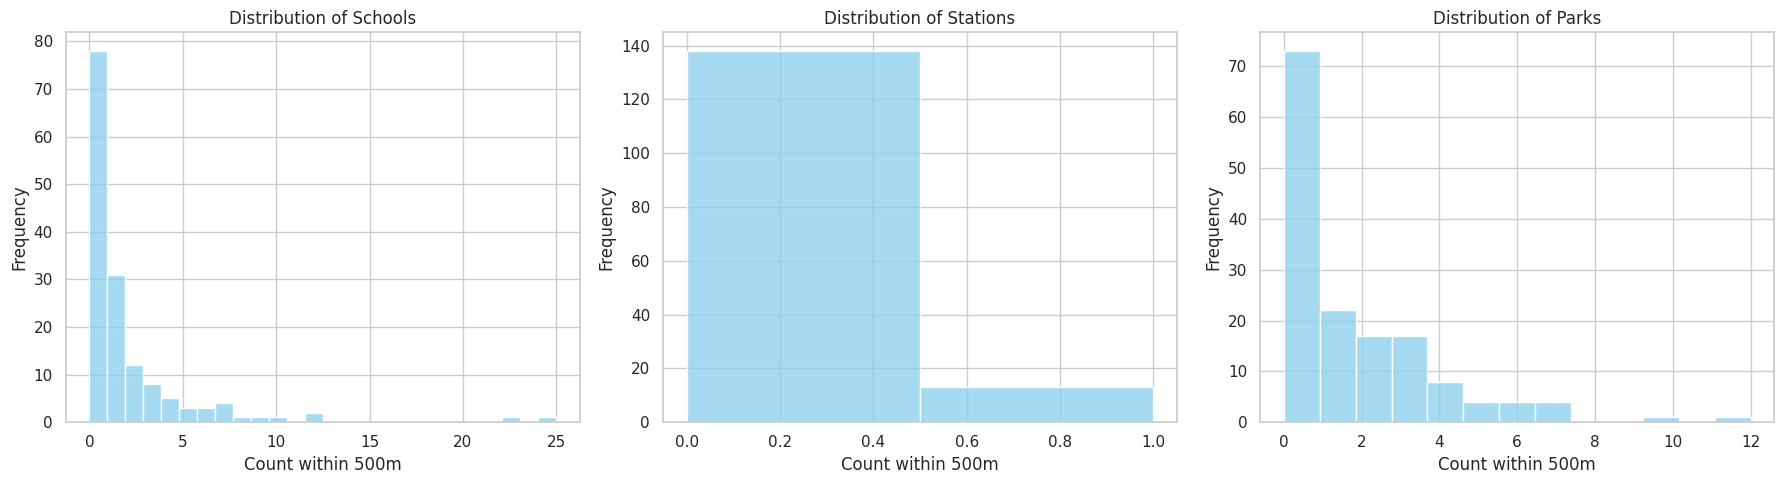

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style='whitegrid')

# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# List of columns to plot
count_cols = ['school_count', 'station_count', 'park_count']
titles = ['Distribution of Schools', 'Distribution of Stations', 'Distribution of Parks']

for i, col in enumerate(count_cols):
    sns.histplot(df_enriched[col], kde=False, ax=axes[i], color='skyblue', bins=max(1, int(df_enriched[col].max() + 1)))
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Count within 500m')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()